In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import PchipInterpolator
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit

In [182]:
CAL_FILE = "data_monochromator_calibration_300V.csv"
FL_FILE  = "data_fluorescence_spectrum_600V.csv"

DRUM_LC_CM = 0.01
GALV_LC_100nA = 0.1

U_DRUM = DRUM_LC_CM / 2.0
U_GALV = GALV_LC_100nA / 2.0

In [183]:
HG_WAVELENGTH_NM = np.array([
    404.7,   # Deep Violet
    407.8,   # Violet
    435.8,   # Indigo - Violet
    491.6,   # Blue - Green
    546.1,   # Green (yellowish)
    577.0,   # Yellow - Orange
    579.1,   # Yellow - Orange
    623.4,   # Red
    690.8,   # Red
])

In [184]:
HG_RELATIVE_INTENSITY = np.array([
    1800,
    150,
    4000,
    80,
    1100,
    240,
    280,
    np.nan,    # table has no relative intensity
    np.nan,    # table has no relative intensity
])

In [185]:
HG_COLOUR = [
    "Violet (deep)",
    "Violet",
    "Indigo-violet",
    "Blue-green (deep-green)",
    "Green (yellowish)",
    "Yellow-orange",
    "Yellow-orange",
    "Red",
    "Red",
]

In [186]:
HG_TABLE = pd.DataFrame({
    "wavelength_nm": HG_WAVELENGTH_NM,
    "colour": HG_COLOUR,
    "relative_intensity": HG_RELATIVE_INTENSITY,
})

print("\n================ MERCURY REFERENCE TABLE ================")
print(HG_TABLE.to_string(index=False))


================ MERCURY REFERENCE TABLE ================
 wavelength_nm                  colour  relative_intensity
         404.7           Violet (deep)              1800.0
         407.8                  Violet               150.0
         435.8           Indigo-violet              4000.0
         491.6 Blue-green (deep-green)                80.0
         546.1       Green (yellowish)              1100.0
         577.0           Yellow-orange               240.0
         579.1           Yellow-orange               280.0
         623.4                     Red                 NaN
         690.8                     Red                 NaN


In [187]:
def read_scan(path):
    df = pd.read_csv(path)

    if df.shape[1] < 2:
        raise ValueError(f"{path} does not contain two columns.")

    d = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy()
    I = pd.to_numeric(df.iloc[:, 1], errors="coerce").to_numpy()

    mask = np.isfinite(d) & np.isfinite(I)
    d, I = d[mask], I[mask]

    idx = np.argsort(d)

    return d[idx], I[idx]


hg_D, hg_I = read_scan(CAL_FILE)
fl_D, fl_I = read_scan(FL_FILE)

print("\n================ DATA SUMMARY ================")
print(f"Hg scan measurements:          {len(hg_D)}")
print(f"Fluorescence measurements:     {len(fl_D)}")
print(f"Drum least count:              {DRUM_LC_CM:.3f} cm")
print(f"Drum standard uncertainty:     {U_DRUM:.5f} cm")
print(f"Galvanometer least count:      {GALV_LC_100nA:.3f} × 100 nA")
print(f"Galvanometer standard error:   {U_GALV:.5f} × 100 nA")



================ DATA SUMMARY ================
Hg scan measurements:          74
Fluorescence measurements:     84
Drum least count:              0.010 cm
Drum standard uncertainty:     0.00500 cm
Galvanometer least count:      0.100 × 100 nA
Galvanometer standard error:   0.05000 × 100 nA


In [188]:
# 3. GENERIC PEAK DETECTION

def smooth(y):
    """Optional visual helper only; never use it for peak amplitudes."""
    n = len(y)
    if n < 7:
        return y.copy()
    window = min(5, n if n % 2 else n - 1)
    if window < 5:
        return y.copy()
    return savgol_filter(y, window_length=window, polyorder=2)


def detect_candidates(D, I, prominence=2.0, use_smoothing=False):
    """Find candidate peaks directly from the measured data by default.

    Smoothing is OFF by default because these scans are sparsely sampled and
    narrow peaks can be attenuated or shifted by smoothing. The measured
    intensities must remain the source of truth for Hg line identification.
    """
    signal = smooth(I) if use_smoothing else I

    idx, props = find_peaks(
        signal,
        prominence=prominence,
        distance=2,
    )

    return D[idx], I[idx], signal, idx, props


In [189]:
# 4. PLOT MERCURY RAW DATA

hg_candidate_D, hg_candidate_I, hg_smooth, hg_peak_idx, hg_props = \
    detect_candidates(hg_D, hg_I, prominence=5.0, use_smoothing=False)


In [190]:
# Inspections
print(hg_candidate_D)
print(type(hg_candidate_D))

print(hg_candidate_I)
print(type(hg_candidate_I))

[13.19 13.51 13.6  15.38 16.29 17.9 ]
<class 'numpy.ndarray'>
[111.2 187.9  79.4 137.3  52.9  15.8]
<class 'numpy.ndarray'>


In [191]:
# Manual Corrections
hg_candidate_D = np.insert(hg_candidate_D, 3, 14.25)
hg_candidate_D = np.insert(hg_candidate_D, 0, 12.87)

hg_candidate_I = np.insert(hg_candidate_I, 3, 12.6)
hg_candidate_I = np.insert(hg_candidate_I, 0, 14.1)

In [192]:
# Inspections post manual edits
print(hg_candidate_D, len(hg_candidate_D))
print(hg_candidate_I, len(hg_candidate_I))

[12.87 13.19 13.51 13.6  14.25 15.38 16.29 17.9 ] 8
[ 14.1 111.2 187.9  79.4  12.6 137.3  52.9  15.8] 8


In [193]:
# Correction 2: Manual Recalib
hg_candidate_D = np.array([13.19, 13.51, 14.25, 15.38, 16.29, 17.9])
hg_candidate_I = np.array([111.2, 187.9, 12.6, 137.3, 52.9, 15.8])

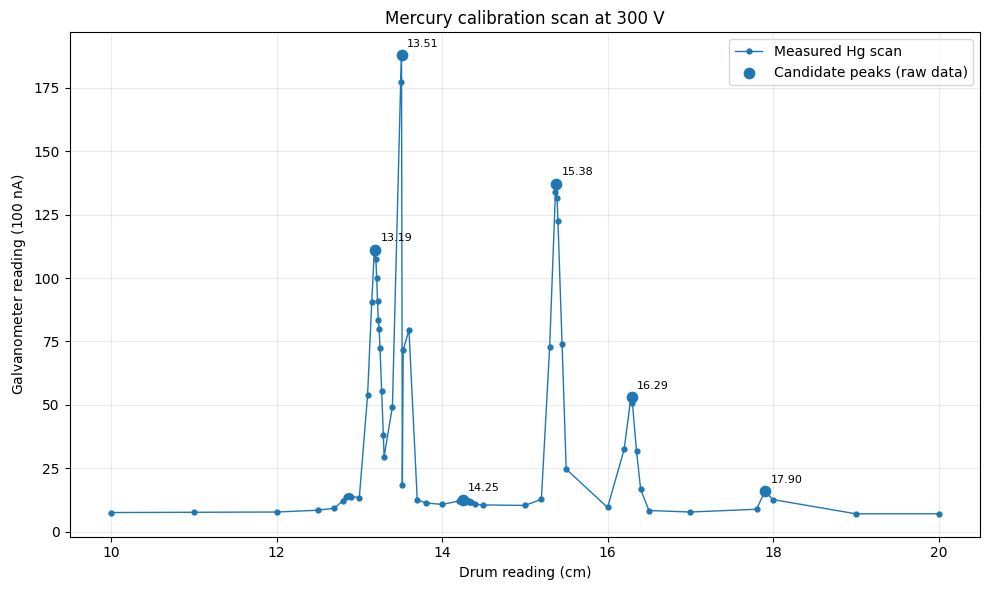


NOTE: Peak detection and calibration use the ORIGINAL measured intensities.
      No smoothing is applied to the Hg scan, because smoothing can
      attenuate or shift narrow peaks, especially with sparse sampling.

================ CANDIDATE Hg PEAKS ================
D = 13.1900 cm, I = 111.20 × 100 nA
D = 13.5100 cm, I = 187.90 × 100 nA
D = 14.2500 cm, I = 12.60 × 100 nA
D = 15.3800 cm, I = 137.30 × 100 nA
D = 16.2900 cm, I = 52.90 × 100 nA
D = 17.9000 cm, I = 15.80 × 100 nA


In [194]:
plt.figure(figsize=(10, 6))
plt.plot(hg_D, hg_I, "o-", ms=3.5, lw=1.0, label="Measured Hg scan")
# Do NOT smooth the calibration scan for plotting: smoothing can suppress
# narrow Hg peaks (as happens near D≈13.51 cm).

plt.scatter(
    hg_candidate_D,
    hg_candidate_I,
    s=55,
    zorder=5,
    label="Candidate peaks (raw data)"
)

for d, I in zip(hg_candidate_D, hg_candidate_I):
    plt.annotate(
        f"{d:.2f}",
        (d, I),
        xytext=(4, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Drum reading (cm)")
plt.ylabel(r"Galvanometer reading ($100$ nA)")
plt.title("Mercury calibration scan at 300 V")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("01_Hg_intensity_vs_drum.png", dpi=300)
plt.show()

print("\nNOTE: Peak detection and calibration use the ORIGINAL measured intensities.")
print("      No smoothing is applied to the Hg scan, because smoothing can")
print("      attenuate or shift narrow peaks, especially with sparse sampling.")

print("\n================ CANDIDATE Hg PEAKS ================")
for d, I in zip(hg_candidate_D, hg_candidate_I):
    print(f"D = {d:.4f} cm, I = {I:.2f} × 100 nA")


In [195]:
# 5. Hg CALIBRATION-POINT REASSIGNMENT 1

CALIBRATION_POINTS_OLD = [
    (17.90, 579.1, "Hg 579.1"),
    (16.29, 577.0, "Hg 577.0"),
    (15.38, 546.1, "Hg 546.1"),
    (14.25, 491.6, "Hg 491.6"),
    (13.53, 435.8, "Hg 435.8"),
    (13.51, 404.7, "Hg 404.7"),
]

CALIBRATION_POINTS_OLD_2 = [(12.87, 623.4, "HG 623.4"),
        (13.19, 579.1, "HG 579.1"),
        (13.51, 577, "HG 577"),
        (13.6, 546.1, "HG 546.1"),
        (14.25, 491.6, "HG 491.6"),
        (15.38, 435.8, "HG 435.8"),
        (16.29, 407.8, "HG 407.8"),
        (17.29, 404.7, "HG 404.7"),]

CALIBRATION_POINTS = [(12.87, 404.7, "HG 404.7"),
        (13.19, 407.8, "HG 407.8"),
        (13.51, 435.8, "HG 435.8"),
        (13.6, 491.6, "HG 491.6"),
        (14.25, 546.1, "HG 546.1"),
        (15.38, 577.0, "HG 577"),
        (16.29, 579.1, "HG 579.1"),
        (17.29, 623.4, "HG 623.4"),]


================ NONLINEAR CALIBRATION ================
Polynomial degree selected: 2
Training RMSE:              20.5847 nm
LOOCV RMSE:                 42.5029 nm

Calibration points:
  HG 404.7: D=12.870 cm -> 404.7 nm
  HG 407.8: D=13.190 cm -> 407.8 nm
  HG 435.8: D=13.510 cm -> 435.8 nm
  HG 491.6: D=13.600 cm -> 491.6 nm
  HG 546.1: D=14.250 cm -> 546.1 nm
    HG 577: D=15.380 cm -> 577.0 nm
  HG 579.1: D=16.290 cm -> 579.1 nm
  HG 623.4: D=17.290 cm -> 623.4 nm

Calibration residuals:
D=  12.870 cm, lambda= 404.70 nm, residual=  +7.087 nm
D=  13.190 cm, lambda= 407.80 nm, residual= -21.924 nm
D=  13.510 cm, lambda= 435.80 nm, residual= -23.420 nm
D=  13.600 cm, lambda= 491.60 nm, residual= +24.555 nm
D=  14.250 cm, lambda= 546.10 nm, residual= +28.685 nm
D=  15.380 cm, lambda= 577.00 nm, residual=  -2.298 nm
D=  16.290 cm, lambda= 579.10 nm, residual= -26.329 nm
D=  17.290 cm, lambda= 623.40 nm, residual= +13.644 nm


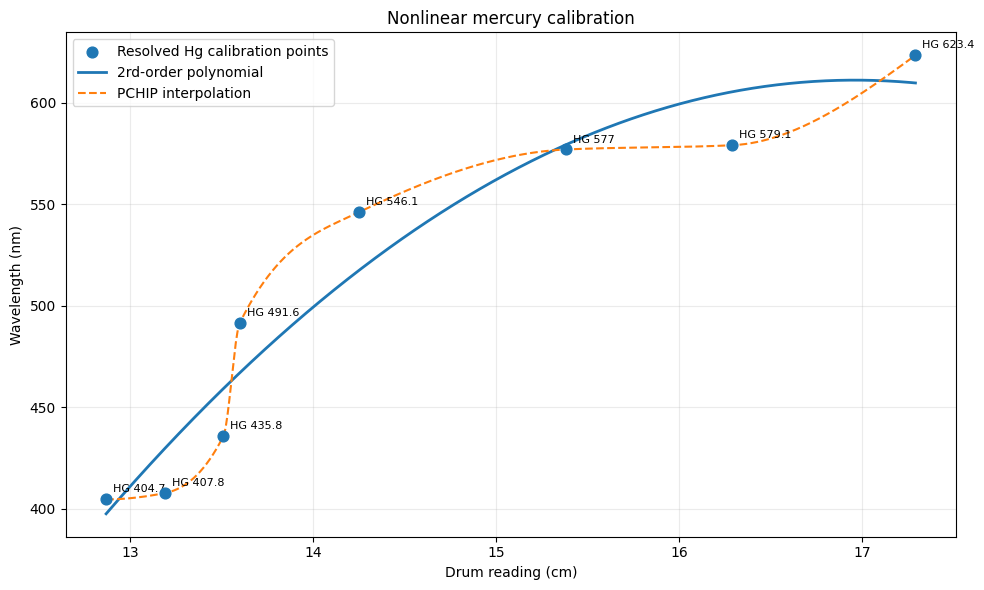

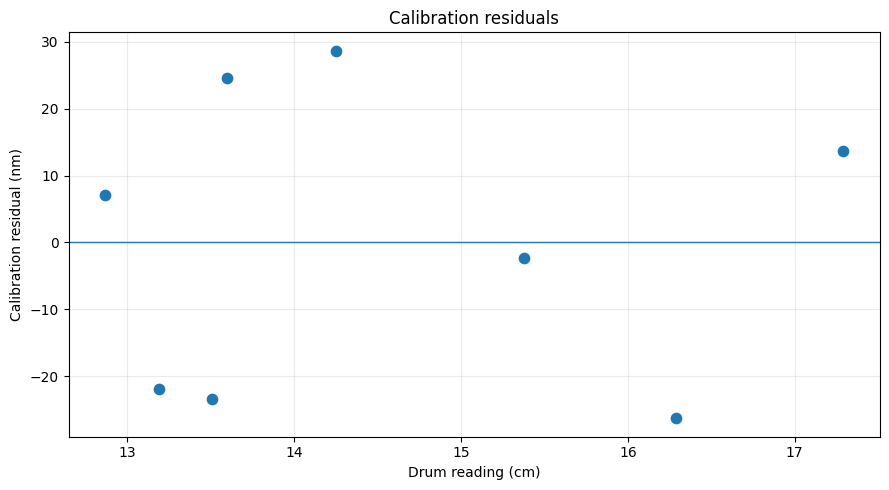

In [196]:
# ==============================================================
# 6. NONLINEAR CALIBRATION
# ==============================================================

def loo_rmse(x, y, degree):
    n = len(x)

    if n <= degree:
        return np.inf

    errors = []

    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False

        coeff = np.polyfit(x[mask], y[mask], degree)
        prediction = np.polyval(coeff, x[i])

        errors.append(y[i] - prediction)

    return float(np.sqrt(np.mean(np.square(errors))))


def fit_polynomial_calibration(Dcal, Lcal):
    """
    Fit a low-order polynomial.
    The degree is chosen using leave-one-out cross-validation and a
    parsimony rule.
    """
    degrees = [d for d in (2, 3) if d < len(Dcal)]

    scores = {d: loo_rmse(Dcal, Lcal, d) for d in degrees}

    best = min(scores.values())

    allowed = [
        d for d in degrees
        if scores[d] <= 1.10 * best
    ]

    degree = min(allowed)

    coeff = np.polyfit(Dcal, Lcal, degree)
    return degree, coeff, scores


Dcal = np.array([p[0] for p in CALIBRATION_POINTS], dtype=float)
Lcal = np.array([p[1] for p in CALIBRATION_POINTS], dtype=float)

# Sort in increasing drum reading.
idx = np.argsort(Dcal)
Dcal = Dcal[idx]
Lcal = Lcal[idx]

# A prism may produce either direction of monotonicity depending on how the
# drum scale is defined. Therefore do NOT hard-code positive d(lambda)/d(D).
dL = np.diff(Lcal)

if not (np.all(dL > 0) or np.all(dL < 0)):
    raise ValueError(
        "Calibration points are not monotonic in wavelength. "
        "Check Hg assignments."
    )

degree, poly_coeff, cv_scores = fit_polynomial_calibration(Dcal, Lcal)

poly = np.poly1d(poly_coeff)

# PCHIP requires x strictly increasing but allows y to be increasing OR decreasing.
pchip = PchipInterpolator(Dcal, Lcal, extrapolate=False)

Lpred = poly(Dcal)
residuals = Lcal - Lpred

rmse_train = np.sqrt(np.mean(residuals**2))
rmse_cv = cv_scores[degree]

print("\n================ NONLINEAR CALIBRATION ================")
print(f"Polynomial degree selected: {degree}")
print(f"Training RMSE:              {rmse_train:.4f} nm")
print(f"LOOCV RMSE:                 {rmse_cv:.4f} nm")

print("\nCalibration points:")
for D, L, point in zip(Dcal, Lcal, sorted(CALIBRATION_POINTS)):
    print(f"{point[2]:>10s}: D={D:.3f} cm -> {L:.1f} nm")

print("\nCalibration residuals:")
for D, L, r in zip(Dcal, Lcal, residuals):
    print(
        f"D={D:8.3f} cm, "
        f"lambda={L:7.2f} nm, "
        f"residual={r:+8.3f} nm"
    )


# ==============================================================
# 7. CALIBRATION PLOT + RESIDUALS
# ==============================================================

Dplot = np.linspace(Dcal.min(), Dcal.max(), 1000)

plt.figure(figsize=(10, 6))
plt.scatter(
    Dcal,
    Lcal,
    s=60,
    zorder=5,
    label="Resolved Hg calibration points"
)
plt.plot(
    Dplot,
    poly(Dplot),
    lw=2.0,
    label=f"{degree}rd-order polynomial"
)
plt.plot(
    Dplot,
    pchip(Dplot),
    "--",
    lw=1.5,
    label="PCHIP interpolation"
)

for D, L, label in CALIBRATION_POINTS:
    if Dmin := Dcal.min() <= D <= Dcal.max():
        pass
    plt.annotate(
        label.replace("Hg ", ""),
        (D, L),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Drum reading (cm)")
plt.ylabel("Wavelength (nm)")
plt.title("Nonlinear mercury calibration")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("02_Hg_nonlinear_calibration.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.axhline(0, lw=1)
plt.scatter(Dcal, residuals, s=55)
plt.xlabel("Drum reading (cm)")
plt.ylabel("Calibration residual (nm)")
plt.title("Calibration residuals")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("03_Hg_calibration_residuals.png", dpi=300)
plt.show()




25 fluorescence points lie outside the Hg calibration range and will not be assigned wavelengths.


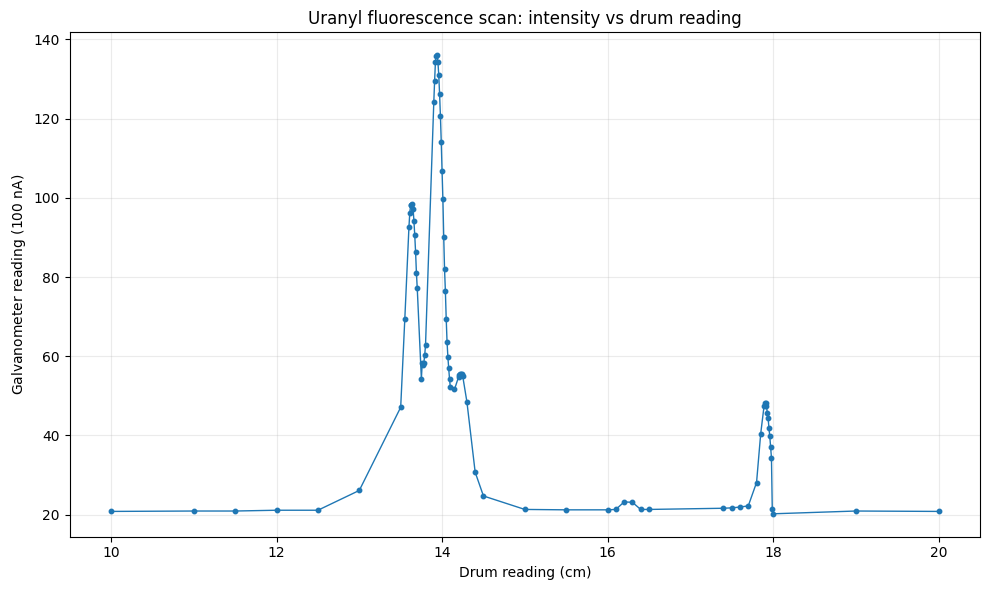

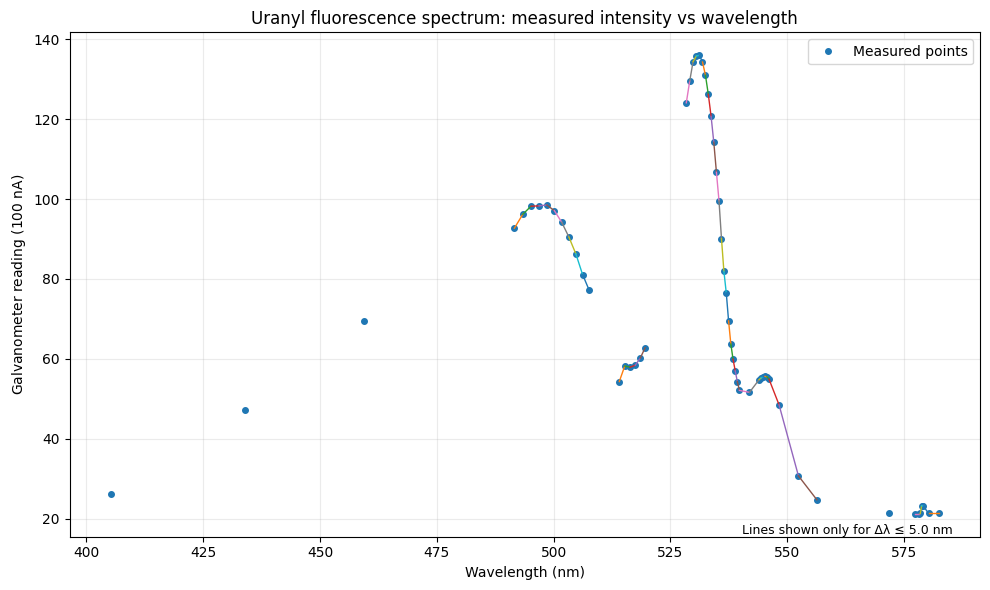


================ WAVELENGTH SAMPLING GAPS ================
405.27 -> 434.05 nm (Δλ = 28.78 nm): no line is drawn across this gap.
434.05 -> 459.47 nm (Δλ = 25.42 nm): no line is drawn across this gap.
459.47 -> 491.60 nm (Δλ = 32.13 nm): no line is drawn across this gap.
507.60 -> 514.05 nm (Δλ = 6.44 nm): no line is drawn across this gap.
519.59 -> 528.39 nm (Δλ = 8.80 nm): no line is drawn across this gap.
556.34 -> 571.84 nm (Δλ = 15.50 nm): no line is drawn across this gap.
571.84 -> 577.41 nm (Δλ = 5.57 nm): no line is drawn across this gap.

================ FLUORESCENCE PEAK CANDIDATES ================
D= 13.6400 cm, lambda≈  498.535 nm, I=   98.50 × 100 nA
D= 13.9400 cm, lambda≈  531.211 nm, I=  136.00 × 100 nA
D= 14.2300 cm, lambda≈  545.246 nm, I=   55.60 × 100 nA


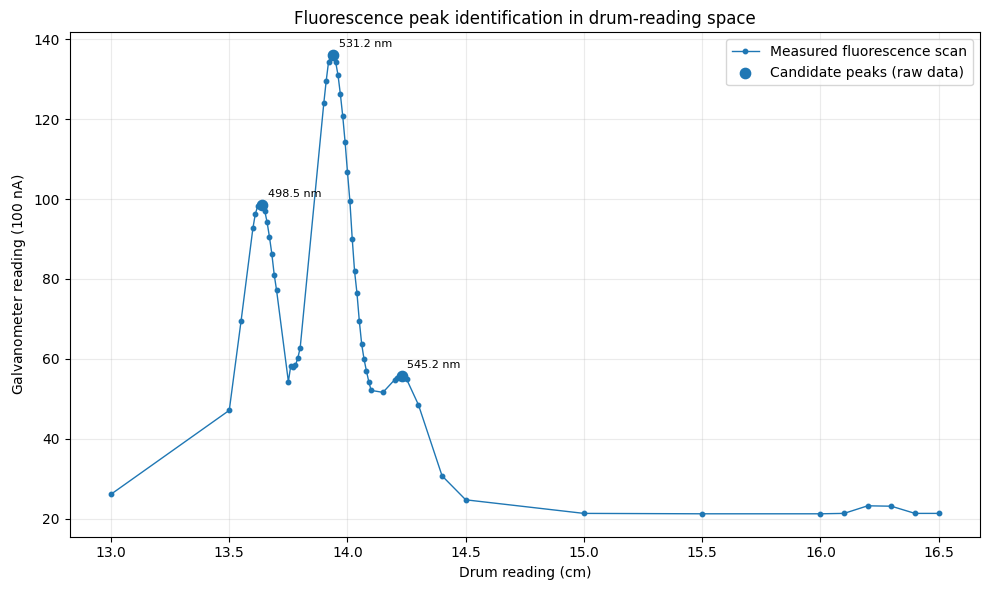

In [197]:

# ==============================================================
# 8. DRUM -> WAVELENGTH CONVERSION
# ==============================================================

"""
For the actual conversion of an unknown spectrum, use PCHIP rather than a
high-order polynomial. PCHIP preserves the monotonic calibration and avoids
unphysical polynomial oscillations.

Most importantly:
    DO NOT extrapolate.
Points outside the measured Hg calibration range are reported separately.
"""

fl_in = (
    (fl_D >= Dcal.min()) &
    (fl_D <= Dcal.max())
)

fl_D_cal = fl_D[fl_in]
fl_I_cal = fl_I[fl_in]

fl_D_outside = fl_D[~fl_in]
fl_I_outside = fl_I[~fl_in]

if len(fl_D_outside):
    print("\nWARNING:")
    print(
        f"{len(fl_D_outside)} fluorescence points lie outside the "
        "Hg calibration range and will not be assigned wavelengths."
    )

fl_lambda = np.asarray(pchip(fl_D_cal), dtype=float)

# Approximate empirical calibration uncertainty:
# use LOOCV error as a practical interpolation/calibration uncertainty.
sigma_cal_nm = rmse_cv


# ==============================================================
# 9. PROPAGATE DRUM UNCERTAINTY INTO WAVELENGTH
# ==============================================================

def derivative_pchip(x):
    return np.asarray(pchip.derivative()(x), dtype=float)

dlambda_dD = derivative_pchip(fl_D_cal)

u_lambda_from_drum = np.abs(dlambda_dD) * U_DRUM

u_lambda_total = np.sqrt(
    u_lambda_from_drum**2 +
    sigma_cal_nm**2
)


# ==============================================================
# 10. FLUORESCENCE: RAW DRUM PLOT
# ==============================================================

plt.figure(figsize=(10, 6))
plt.plot(fl_D, fl_I, "o-", ms=3.2, lw=1.0)
plt.xlabel("Drum reading (cm)")
plt.ylabel(r"Galvanometer reading ($100$ nA)")
plt.title("Uranyl fluorescence scan: intensity vs drum reading")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("04_fluorescence_intensity_vs_drum.png", dpi=300)
plt.show()


# ==============================================================
# 11. FLUORESCENCE: WAVELENGTH PLOT
# ==============================================================

order = np.argsort(fl_lambda)

lam_sorted = fl_lambda[order]
I_sorted = fl_I_cal[order]
u_lam_sorted = u_lambda_total[order]

# Do not connect widely separated wavelength measurements.
# Such straight lines would be interpolation, not measured spectral structure.
wavelength_gap_threshold_nm = 5.0

plt.figure(figsize=(10, 6))
plt.plot(
    lam_sorted,
    I_sorted,
    linestyle="None",
    marker="o",
    markersize=4,
    label="Measured points",
)

# Connect points only when they are densely sampled in wavelength.
for i in range(len(lam_sorted) - 1):
    gap = lam_sorted[i + 1] - lam_sorted[i]

    if gap <= wavelength_gap_threshold_nm:
        plt.plot(
            [lam_sorted[i], lam_sorted[i + 1]],
            [I_sorted[i], I_sorted[i + 1]],
            linewidth=1.0,
        )

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"Galvanometer reading ($100$ nA)")
plt.title("Uranyl fluorescence spectrum: measured intensity vs wavelength")
plt.grid(alpha=0.25)
plt.legend()
plt.text(
    0.97,
    0.000,
    f"Lines shown only for Δλ ≤ {wavelength_gap_threshold_nm:.1f} nm",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(
    "05_fluorescence_intensity_vs_wavelength_no_artificial_gaps.png",
    dpi=300,
)
plt.show()

large_gap_idx = np.where(
    np.diff(lam_sorted) > wavelength_gap_threshold_nm
)[0]

print("\n================ WAVELENGTH SAMPLING GAPS ================")
if len(large_gap_idx) == 0:
    print("No wavelength gaps larger than the threshold.")
else:
    for i in large_gap_idx:
        print(
            f"{lam_sorted[i]:.2f} -> {lam_sorted[i+1]:.2f} nm "
            f"(Δλ = {lam_sorted[i+1] - lam_sorted[i]:.2f} nm): "
            "no line is drawn across this gap."
        )


# ==============================================================
# 12. AUTOMATIC FLUORESCENCE PEAK CANDIDATES
# ==============================================================

# IMPORTANT:
# Peak identification is performed directly in DRUM space using the RAW
# measured fluorescence points. No global smoothing and no wavelength-space
# interpolation are used to find peaks.
#
# Only after a drum-space peak has been identified do we convert its position
# to wavelength with the calibration function.

candidate_signal = fl_I_cal

candidate_idx, candidate_props = find_peaks(
    candidate_signal,
    prominence=3.0,
    distance=2,
)

candidate_D = fl_D_cal[candidate_idx]
candidate_I = fl_I_cal[candidate_idx]
candidate_lambda = np.asarray(pchip(candidate_D), dtype=float)

print("\n================ FLUORESCENCE PEAK CANDIDATES ================")
for D, I, L in zip(candidate_D, candidate_I, candidate_lambda):
    print(
        f"D={D:8.4f} cm, "
        f"lambda≈{L:9.3f} nm, "
        f"I={I:8.2f} × 100 nA"
    )

plt.figure(figsize=(10, 6))
plt.plot(
    fl_D_cal,
    fl_I_cal,
    "o-",
    ms=3.2,
    lw=1.0,
    label="Measured fluorescence scan",
)
plt.scatter(
    candidate_D,
    candidate_I,
    s=55,
    zorder=5,
    label="Candidate peaks (raw data)",
)

for D, I, L in zip(candidate_D, candidate_I, candidate_lambda):
    plt.annotate(
        f"{L:.1f} nm",
        (D, I),
        xytext=(4, 6),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel("Drum reading (cm)")
plt.ylabel(r"Galvanometer reading ($100$ nA)")
plt.title("Fluorescence peak identification in drum-reading space")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(
    "06_candidate_fluorescence_peaks_in_drum_space.png",
    dpi=300,
)
plt.show()

In [198]:
FLUORESCENCE_BAND_DRUMS = [
    13.64, 13.94, 14.23
]


================ FINAL FLUORESCENCE BANDS ================
v=0  D=13.63153±0.00538 cm  lambda=497.128±42.513 nm  nu_bar=20115.53±1720.20 cm^-1
v=1  D=13.93486±0.00501 cm  lambda=530.868±42.504 nm  nu_bar=18837.08±1508.20 cm^-1
v=2  D=14.22790±0.00507 cm  lambda=545.157±42.503 nm  nu_bar=18343.35±1430.15 cm^-1

================ ADJACENT SPACINGS ================
(0-0) -> (0-1): 1278.45 ± 2287.74 cm^-1
(0-1) -> (0-2): 493.73 ± 2078.46 cm^-1

Mean adjacent spacing = 886.09 cm^-1
SEM from band-to-band spread = 392.36 cm^-1

================ VIBRONIC REGRESSION ================
nu_00 = 19950.88 ± 1529.13 cm^-1
omega_e = 860.67 ± 1111.89 cm^-1
R^2 = 0.937752

================ 0-0 TRANSITION ================
lambda_00 = 497.128 ± 42.513 nm
nu_00 = 19950.88 ± 1529.13 cm^-1
E_00 = 2.473594 ± 0.189587 eV

================ FORCE CONSTANT ================
f = (6.98260e+05 ± 1.80e+06) dyn/cm
f = (6.98260e+02 ± 1.80e+03) N/m


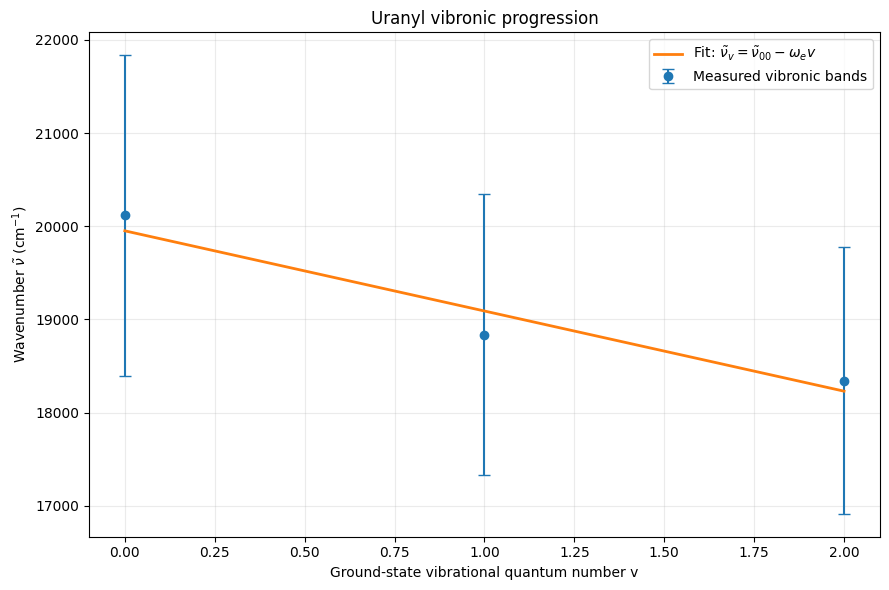


================ ERROR BUDGET ================

Instrumental/readout:
  Drum LC = 0.010 cm
  Drum reading uncertainty = ±0.00500 cm (half least count)
  Galvanometer LC = 0.100 × 100 nA
  Galvanometer reading uncertainty = ±0.05000 × 100 nA (half least count)

Calibration:
  Polynomial training RMSE = 20.5847 nm
  LOOCV calibration uncertainty = 42.5029 nm

Statistical/internal consistency:
  Adjacent spacing SEM = 392.3616 cm^-1
  Weighted-fit uncertainty in omega_e = 1111.8931 cm^-1

Systematic effects that cannot be reliably assigned numerical values
from this single scan:
  • mechanical backlash
  • slit-width / instrumental spectral resolution
  • PMT gain drift
  • lamp intensity drift
  • background / stray light
  • unresolved Hg doublets
  • incorrect peak assignment
  • interpolation/model inadequacy

Do not combine these unquantified systematic effects into a numerical ± error unless they were experimentally measured (for example by repeated scans, reverse-direction scans, 

In [199]:

# ==============================================================
# 14. LOCAL PEAK-CENTER FIT
# ==============================================================

def local_quadratic_peak(D, I, D_guess, half_width=0.025):
    """
    Fit:
        I(D) = a(D-D0)^2 + b(D-D0) + c

    and calculate the maximum:
        D_peak = D0 - b/(2a)

    The covariance matrix gives a statistical uncertainty on the fitted
    peak center, conditional on the local quadratic model.
    """
    mask = np.abs(D - D_guess) <= half_width

    if mask.sum() < 5:
        raise ValueError(
            f"Not enough data around D={D_guess:.4f} cm "
            "for a peak-center fit."
        )

    x = D[mask]
    y = I[mask]

    x0 = np.mean(x)
    u = x - x0

    def quad(u, a, b, c):
        return a*u*u + b*u + c

    popt, pcov = curve_fit(
        quad,
        u,
        y,
        p0=(-1.0, 0.0, np.max(y)),
        maxfev=10000,
    )

    a, b, c = popt

    if a >= 0:
        raise ValueError(
            f"Peak at D={D_guess:.4f} cm does not have a concave-down "
            "local quadratic fit."
        )

    u_peak = -b / (2.0 * a)
    D_peak = x0 + u_peak

    # Gradient of -b/(2a) wrt [a,b,c]
    grad = np.array([
        b/(2.0*a*a),
        -1.0/(2.0*a),
        0.0
    ])

    variance = float(grad @ pcov @ grad)
    u_D_fit = np.sqrt(max(variance, 0.0))

    return D_peak, u_D_fit


# ==============================================================
# 15. BAND EXTRACTION + WAVENUMBER UNCERTAINTY
# ==============================================================

if not FLUORESCENCE_BAND_DRUMS:
    print("\n================ FINAL BAND ANALYSIS ================")
    print(
        "No final fluorescence-band positions were entered.\n"
        "Add verified values to FLUORESCENCE_BAND_DRUMS and rerun."
    )
    raise SystemExit


def wavelength_to_wavenumber(lambda_nm):
    return 1.0e7 / np.asarray(lambda_nm)


def u_wavenumber_from_u_lambda(lambda_nm, u_lambda_nm):
    return (
        1.0e7 / lambda_nm**2
    ) * u_lambda_nm


band_results = []

for D_guess in FLUORESCENCE_BAND_DRUMS:

    # First determine the peak center in drum space from the raw data.
    # Only then convert that peak center to wavelength.

    D_peak, u_D_fit = local_quadratic_peak(
    fl_D,
    fl_I,
    D_guess,
    half_width=0.025
    )

    lambda_peak = float(pchip(D_peak))

    slope = float(pchip.derivative()(D_peak))

    # Combine the half-least-count reading uncertainty and the fitted
    # peak-center uncertainty as independent contributions.
    u_D_total = np.sqrt(
        U_DRUM**2 +
        u_D_fit**2
    )

    u_lambda_reading = abs(slope) * u_D_total

    # Combine with empirical calibration uncertainty.
    u_lambda = np.sqrt(
        u_lambda_reading**2 +
        sigma_cal_nm**2
    )

    nubar = float(wavelength_to_wavenumber(lambda_peak))
    u_nubar = float(
        u_wavenumber_from_u_lambda(lambda_peak, u_lambda)
    )

    band_results.append({
        "D_cm": D_peak,
        "u_D_cm": u_D_total,
        "lambda_nm": lambda_peak,
        "u_lambda_nm": u_lambda,
        "wavenumber_cm-1": nubar,
        "u_wavenumber_cm-1": u_nubar,
    })


# Highest-energy/shortest-wavelength member is assigned v=0.
band_results.sort(key=lambda r: r["lambda_nm"])

for v, r in enumerate(band_results):
    r["v"] = v


print("\n================ FINAL FLUORESCENCE BANDS ================")

for r in band_results:
    print(
        f"v={r['v']:d}  "
        f"D={r['D_cm']:.5f}±{r['u_D_cm']:.5f} cm  "
        f"lambda={r['lambda_nm']:.3f}±{r['u_lambda_nm']:.3f} nm  "
        f"nu_bar={r['wavenumber_cm-1']:.2f}"
        f"±{r['u_wavenumber_cm-1']:.2f} cm^-1"
    )


# ==============================================================
# 16. ADJACENT VIBRATIONAL SPACINGS
# ==============================================================

nu = np.array([r["wavenumber_cm-1"] for r in band_results])
u_nu = np.array([r["u_wavenumber_cm-1"] for r in band_results])

if len(nu) < 3:
    raise ValueError(
        "At least three bands are required for a useful vibronic "
        "progression analysis."
    )

spacing = nu[:-1] - nu[1:]

# Propagate uncertainty for each adjacent difference.
u_spacing = np.sqrt(
    u_nu[:-1]**2 +
    u_nu[1:]**2
)

mean_spacing = np.mean(spacing)
u_spacing_sem = (
    np.std(spacing, ddof=1) / np.sqrt(len(spacing))
    if len(spacing) > 1 else np.nan
)

print("\n================ ADJACENT SPACINGS ================")

for i, (s, us) in enumerate(zip(spacing, u_spacing)):
    print(
        f"(0-{i}) -> (0-{i+1}): "
        f"{s:.2f} ± {us:.2f} cm^-1"
    )

print(
    f"\nMean adjacent spacing = "
    f"{mean_spacing:.2f} cm^-1"
)

print(
    f"SEM from band-to-band spread = "
    f"{u_spacing_sem:.2f} cm^-1"
)


# ==============================================================
# 17. WEIGHTED LINEAR REGRESSION OF VIBRONIC PROGRESSION
# ==============================================================

"""
Fit:
    nu_bar(v) = nu_00 - omega_e*v

This simultaneously uses all measured bands and is preferable to estimating
omega_e from only one pair.

Important:
The spacing scatter and the formal regression uncertainty describe
different things:

  - regression uncertainty: propagation of the estimated wavelength errors;
  - spacing scatter: empirical reproducibility/internal consistency of the
    observed progression.

Report both where appropriate.
"""

v = np.array([r["v"] for r in band_results], dtype=float)


def vibronic_line(v, nu00, omega):
    return nu00 - omega*v


popt, pcov = curve_fit(
    vibronic_line,
    v,
    nu,
    sigma=u_nu,
    absolute_sigma=True,
    p0=[nu[0], mean_spacing],
)

nu00_fit = float(popt[0])
omega_e_fit = float(popt[1])

u_nu00_fit = float(np.sqrt(pcov[0, 0]))
u_omega_fit = float(np.sqrt(pcov[1, 1]))

prediction = vibronic_line(v, *popt)
residual = nu - prediction

ss_res = np.sum(residual**2)
ss_tot = np.sum((nu - np.mean(nu))**2)

R2 = (
    1 - ss_res/ss_tot
    if ss_tot != 0
    else np.nan
)

print("\n================ VIBRONIC REGRESSION ================")
print(
    f"nu_00 = {nu00_fit:.2f} ± {u_nu00_fit:.2f} cm^-1"
)
print(
    f"omega_e = {omega_e_fit:.2f} ± {u_omega_fit:.2f} cm^-1"
)
print(f"R^2 = {R2:.6f}")


# ==============================================================
# 18. 0-0 WAVELENGTH + FIRST ELECTRONIC EXCITATION ENERGY
# ==============================================================

"""
The 0-0 band gives the origin transition in the simple model because v=0:
    nu_(0-0) = nu_00

Energy:
    E_00 = h c nu_00

In eV:
    E[eV] = 1.239841984e-4 * nu[cm^-1]
"""

lambda00 = band_results[0]["lambda_nm"]
u_lambda00 = band_results[0]["u_lambda_nm"]

E00_eV = 1.239841984e-4 * nu00_fit
u_E00_eV = 1.239841984e-4 * u_nu00_fit

print("\n================ 0-0 TRANSITION ================")
print(
    f"lambda_00 = "
    f"{lambda00:.3f} ± {u_lambda00:.3f} nm"
)
print(
    f"nu_00 = "
    f"{nu00_fit:.2f} ± {u_nu00_fit:.2f} cm^-1"
)
print(
    f"E_00 = "
    f"{E00_eV:.6f} ± {u_E00_eV:.6f} eV"
)


# ==============================================================
# 19. FORCE CONSTANT
# ==============================================================

"""
Harmonic symmetric-stretch relation:

    omega_e = [1/(2*pi*c)] sqrt(f/m_O)

where:
    omega_e is in cm^-1
    c is in cm/s
    m_O is in grams

Therefore:

    f = m_O (2*pi*c*omega_e)^2

For oxygen:
    m_O = 15.999 amu

and

    f[dyn/cm]
      = m_O[amu] * m_u[g] * (2*pi*c*omega_e)^2

This makes:
    f ∝ omega_e^2

and hence:

    u_f/f = 2 u_omega/omega

NOTE:
A previous analysis draft incorrectly contained a square-root dependence
on omega_e. That is inconsistent with the harmonic-oscillator equation
above and is corrected here.
"""

AMU_TO_G = 1.66053906660e-24
C_CGS = 2.99792458e10

mO_g = 15.999 * AMU_TO_G

force_dyne_cm = (
    mO_g *
    (2.0*np.pi*C_CGS*omega_e_fit)**2
)

u_force_dyne_cm = (
    force_dyne_cm *
    2.0 *
    abs(u_omega_fit / omega_e_fit)
)

# 1 dyne/cm = 1e-3 N/m
force_N_m = force_dyne_cm * 1e-3
u_force_N_m = u_force_dyne_cm * 1e-3

print("\n================ FORCE CONSTANT ================")
print(
    f"f = ({force_dyne_cm:.5e} ± "
    f"{u_force_dyne_cm:.2e}) dyn/cm"
)
print(
    f"f = ({force_N_m:.5e} ± "
    f"{u_force_N_m:.2e}) N/m"
)


# ==============================================================
# 20. VIBRONIC PROGRESSION PLOT
# ==============================================================

plt.figure(figsize=(9, 6))

plt.errorbar(
    v,
    nu,
    yerr=u_nu,
    fmt="o",
    capsize=4,
    label="Measured vibronic bands"
)

vv = np.linspace(v.min(), v.max(), 200)

plt.plot(
    vv,
    vibronic_line(vv, *popt),
    lw=2,
    label=r"Fit: $\tilde{\nu}_v=\tilde{\nu}_{00}-\omega_e v$"
)

plt.xlabel("Ground-state vibrational quantum number v")
plt.ylabel(r"Wavenumber $\tilde{\nu}$ (cm$^{-1}$)")
plt.title("Uranyl vibronic progression")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("07_vibronic_progression.png", dpi=300)
plt.show()


# ==============================================================
# 21. ERROR BUDGET
# ==============================================================

print("\n================ ERROR BUDGET ================")

print("\nInstrumental/readout:")
print(
    f"  Drum LC = {DRUM_LC_CM:.3f} cm"
)
print(
    f"  Drum reading uncertainty = ±{U_DRUM:.5f} cm (half least count)"
)
print(
    f"  Galvanometer LC = {GALV_LC_100nA:.3f} × 100 nA"
)
print(
    f"  Galvanometer reading uncertainty = ±{U_GALV:.5f} × 100 nA (half least count)"
)

print("\nCalibration:")
print(
    f"  Polynomial training RMSE = {rmse_train:.4f} nm"
)
print(
    f"  LOOCV calibration uncertainty = {sigma_cal_nm:.4f} nm"
)

print("\nStatistical/internal consistency:")
print(
    f"  Adjacent spacing SEM = {u_spacing_sem:.4f} cm^-1"
)
print(
    f"  Weighted-fit uncertainty in omega_e = {u_omega_fit:.4f} cm^-1"
)

print("\nSystematic effects that cannot be reliably assigned numerical values")
print("from this single scan:")
print("  • mechanical backlash")
print("  • slit-width / instrumental spectral resolution")
print("  • PMT gain drift")
print("  • lamp intensity drift")
print("  • background / stray light")
print("  • unresolved Hg doublets")
print("  • incorrect peak assignment")
print("  • interpolation/model inadequacy")

print(
    "\nDo not combine these unquantified systematic effects into a numerical "
    "± error unless they were experimentally measured (for example by "
    "repeated scans, reverse-direction scans, independent calibration, "
    "background measurements, or resolution measurements)."
)


# ==============================================================
# 22. SAVE MACHINE-READABLE RESULTS
# ==============================================================

results = pd.DataFrame(band_results)

results_file = "uranyl_vibronic_band_results.csv"
results.to_csv(results_file, index=False)

print(
    f"\nBand results saved to:\n{results_file}"
)

print("\n================ ANALYSIS COMPLETE ================")